#Этап 2. Построение и анализ базовых моделей

В качестве базового алгоритма было выбрано решающее дерево (`DecisionTreeRegressor`)

#Этап 2.1 Добавление библиотек и чтение файлов:

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Загружаем данные (устойчиво к рабочей директории ядра)
cwd = Path.cwd()
if (cwd / 'data' / 'processed').exists():
    processed_dir = cwd / 'data' / 'processed'
elif (cwd.parent / 'data' / 'processed').exists():
    processed_dir = cwd.parent / 'data' / 'processed'
else:
    # Последняя попытка — относительный путь
    processed_dir = Path('../data/processed')

train_path = processed_dir / 'train_ordinal_encoded.csv'
test_path = processed_dir / 'test_ordinal_encoded.csv'
val_path = processed_dir / 'validation_ordinal_encoded.csv'
#print('Используем processed_dir =', processed_dir.resolve())
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
val_df = pd.read_csv(val_path)
# Разделяем на признаки (X) и целевую переменную (y)
# (Убедитесь, что название колонки целевой переменной - 'charges')
X_train = train_df.drop('charges', axis=1)
y_train = train_df['charges']
X_test = test_df.drop('charges', axis=1)
y_test = test_df['charges']
X_val = val_df.drop('charges', axis=1)
y_val = val_df['charges']

print('Данные успешно загружены и разделены на X и y.')
print(f"Размер тренировочной выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Размер валидационной выборки: {X_val.shape}")

Данные успешно загружены и разделены на X и y.
Размер тренировочной выборки: (802, 6)
Размер тестовой выборки: (268, 6)
Размер валидационной выборки: (268, 6)


##Этап 2.2 Построим "Жадное" дерево, без ограничений глубины.


Первый шаг в анализе решающих деревьев — построение модели «по умолчанию», то есть без каких-либо ограничений на рост структуры (без указания `max_depth`). Такие деревья называют **«жадными»**, так как они продолжают дробить выборку до тех пор, пока в каждом конечном листе не останется минимально возможное количество объектов. Они будет расти, пока идеально не выучат Train.

~*зачем мы это делаем?*~

1. *Чтобы иметь точку отчета и показать эффект* **<До/После>** 
2. Зафиксировать худший сценарий.
3.  Показать проблему высокого разброса(High Variance)

и т.д.

In [8]:
# Обучаем дерево без ограничений
tree_unlimited = DecisionTreeRegressor(random_state=42)
tree_unlimited.fit(X_train, y_train)

# Считаем предсказания
y_train_pred = tree_unlimited.predict(X_train)
y_val_pred = tree_unlimited.predict(X_val)

# Проверяем метрики переобучения
print("Метрики на Train (должны быть идеальными):")
print(f"R2: {r2_score(y_train, y_train_pred):.4f} | MAE: ${mean_absolute_error(y_train, y_train_pred):.2f} | RMSE: ${root_mean_squared_error(y_train, y_train_pred):.2f}")

print("\nМетрики на Validation (покажут реальное качество):")
print(f"R2: {r2_score(y_val, y_val_pred):.4f} | MAE: ${mean_absolute_error(y_val, y_val_pred):.2f} | RMSE: ${root_mean_squared_error(y_val, y_val_pred):.2f}")

Метрики на Train (должны быть идеальными):
R2: 1.0000 | MAE: $0.00 | RMSE: $0.00

Метрики на Validation (покажут реальное качество):
R2: 0.7030 | MAE: $3262.99 | RMSE: $6750.74


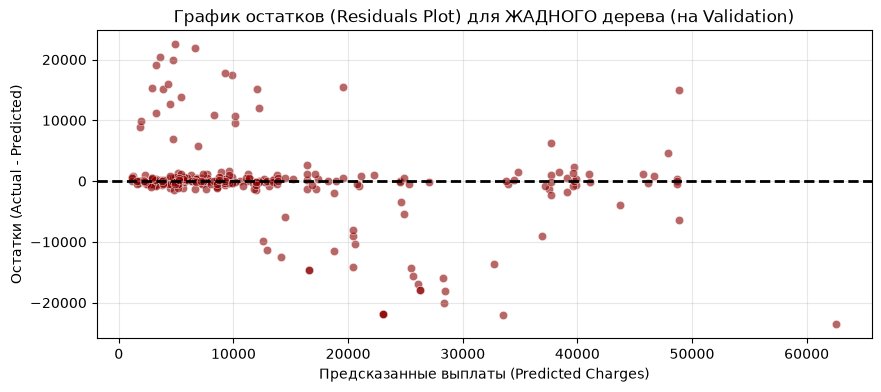

In [10]:
#График остатков для жадного дерева на валидации
residuals_unlimited = y_val - y_val_pred
plt.figure(figsize=(10, 4))
sns.scatterplot(x=y_val_pred, y=residuals_unlimited, alpha=0.6, color='darkred')
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
plt.title('График остатков (Residuals Plot) для ЖАДНОГО дерева (на Validation)')
plt.xlabel('Предсказанные выплаты (Predicted Charges)')
plt.ylabel('Остатки (Actual - Predicted)')
plt.grid(True, alpha=0.3)
plt.show()

#### Мы видим, что метрики на Train очень близки к идеальным, модель подстроилась под каждого конкретного человека из обучающего набора и запомнила его идеальную стоимость. Но, как только появляются новые пациенты, она начинает допускать огромные ошибки.

## Что означают метрики R2 и MAE?

Мы будем использовать 4 вида метрик:

1. **$MAE$(средняя абсолютная ошибка)** - находит среднее арифметическое всех ошибок(если модель ошиблась на 100 долларов вниз или вверх, для нее это одна и та же стоимость - 100 единиц)
2. **$MSE$(средняя квадратичная ошибка)** - возводит в квадрат ошибку перед усреднением. Измеряется в "квадратичных долларах" ($\$^2$)
3. **$RMSE$(корень из средней квадратичной ошибки)** - берет корень от MSE, то есть считывает также все в квадрате, но от среднего числа берет корень. RMSE очень чувствителен к крупным ошибкам (выбросам)
4. **$R^2$ (R2, коэффициент детерминации)** - Показывает долю объясненной дисперсии. Сравнивает модель с глупым предсказанием среднего значения для каждого пациента. Обычно от 0 до 1, но бывает и отрицательные значения(то есть лучше было бы использовать среднее значение для всех, чем использовать такой вариант).
    * $R^2 = 1$: Идеальное предсказание.
   * $R^2 = 0$: Модель работает на уровне предсказания константы (среднего).
   * $R^2 < 0$: Модель работает хуже, чем простое предсказание среднего значения.

### Этап 2.3. Оптимизация гиперпараметров и борьба с переобучением

Как продемонстрировал предыдущий шаг, «жадное» дерево решений без ограничений переобучается: оно идеально запоминает тренировочный набор, но теряет обобщающую способность на новых данных. Чтобы решить эту проблему, необходимо провести регуляризацию (подрезку) дерева. Главным гиперпараметром в данном случае выступает максимальная глубина (`max_depth`).

В этой ячейке мы реализуем процесс ручного поиска оптимальной глубины:
1. Обучим последовательность моделей с ограничением `max_depth` в диапазоне от 1 до 15.
2. Для каждого шага посчитаем метрику качества $R^2$ на обучающей выборке (`Train`) и на валидационной выборке (`Validation`).
3. Построим график кривых обучения (Learning Curves).


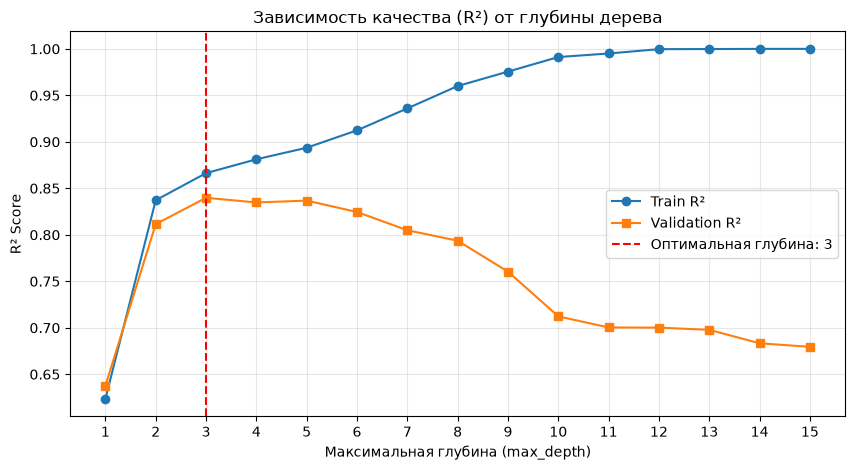

Оптимальная глубина дерева (max_depth): 3
Максимальный R² на валидации: 0.8398


In [11]:
depths = range(1, 16)
train_r2_scores = []
val_r2_scores = []

# Обучаем деревья с разной глубиной и записываем их R2
for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    
    train_r2_scores.append(r2_score(y_train, tree.predict(X_train)))
    val_r2_scores.append(r2_score(y_val, tree.predict(X_val)))

# Ищем глубину с максимальным R2 на валидации
best_depth = depths[np.argmax(val_r2_scores)]
best_val_score = max(val_r2_scores)

# Строим график зависимости качества от глубины
plt.figure(figsize=(10, 5))
plt.plot(depths, train_r2_scores, label='Train R²', marker='o')
plt.plot(depths, val_r2_scores, label='Validation R²', marker='s')
plt.axvline(x=best_depth, color='red', linestyle='--', label=f'Оптимальная глубина: {best_depth}')
plt.title('Зависимость качества (R²) от глубины дерева')
plt.xlabel('Максимальная глубина (max_depth)')
plt.ylabel('R² Score')
plt.xticks(depths)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Оптимальная глубина дерева (max_depth): {best_depth}")
print(f"Максимальный R² на валидации: {best_val_score:.4f}")

### Этап 2.4. Финальное тестирование модели и визуальный анализ ошибок

На основе построенного графика зависимости качества от сложности модели мы определили оптимальное значение `max_depth`, при котором достигается наилучший баланс между смещением и разбросом (Bias-Variance Trade-off).Мы видим, что Train-линия постоянно идет вверх, а Validation после глубины 3 начинает падать (модель переобучается).
Так как теперь у нас есть оптимальная глубина, используем ее и обучим модель. Прогоним через нее наши тестовые данные, чтобы получить финальные метрики и построить график остатков.

В данной ячейке мы переходим к финальному этапу построения базовой модели:
1. Обучаем итоговое дерево решений с зафиксированным оптимальным значением глубины.
2. Впервые извлекаем из «сейфа» отложенную **тестовую выборку (`Test`)** и делаем по ней предсказания. Метрики ($R^2$, MAE, RMSE) на тесте покажут реальное, честное качество работы модели в продакшене.
3. Строим **график остатков (Residuals Plot)** для визуального анализа характера ошибок.



=== ФИНАЛЬНЫЕ МЕТРИКИ НА TEST ===
Test R²:   0.8219
Test MAE:  $2823.75
Test RMSE: $4746.76


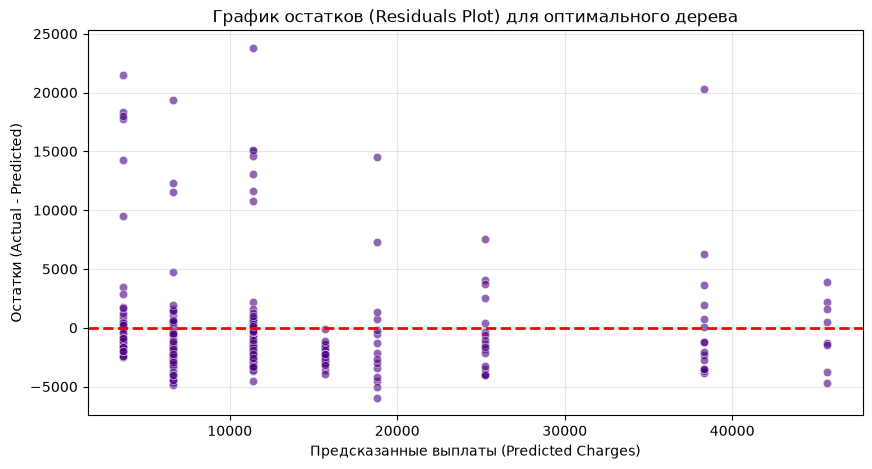

In [12]:
# Обучаем финальное дерево с оптимальной глубиной
best_tree = DecisionTreeRegressor(max_depth=best_depth, random_state=42)

# Можно объединить Train и Val для финального обучения (опционально, но полезно)
# Так как Test у нас отложен отдельно, модель получит больше данных
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

best_tree.fit(X_train_full, y_train_full)

# Делаем финальные предсказания на скрытой тестовой выборке
y_test_pred = best_tree.predict(X_test)

print("=== ФИНАЛЬНЫЕ МЕТРИКИ НА TEST ===")
print(f"Test R²:   {r2_score(y_test, y_test_pred):.4f}")
print(f"Test MAE:  ${mean_absolute_error(y_test, y_test_pred):.2f}")
print(f"Test RMSE: ${root_mean_squared_error(y_test, y_test_pred):.2f}")

# Пункт 5 плана: Визуальный анализ ошибок (График остатков)
residuals = y_test - y_test_pred

plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.6, color='indigo')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('График остатков (Residuals Plot) для оптимального дерева')
plt.xlabel('Предсказанные выплаты (Predicted Charges)')
plt.ylabel('Остатки (Actual - Predicted)')
plt.grid(True, alpha=0.3)
plt.show()

### Этап 2.5. Интерпретация модели: Важность признаков (Feature Importance)
Решающие деревья обладают встроенным механизмом оценки важности факторов. Посмотрим, какие именно характеристики клиентов медицинского страхования оказались ключевыми для принятия решений нашей оптимальной моделью.

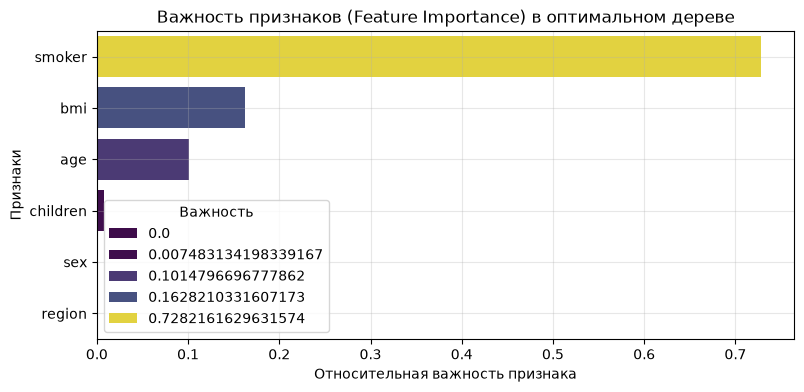

 Признак  Важность
  smoker  0.728216
     bmi  0.162821
     age  0.101480
children  0.007483
     sex  0.000000
  region  0.000000


In [14]:
# Получаем важность признаков из финального оптимального дерева
importances = best_tree.feature_importances_
features = X_train.columns

# Создаем датафрейм для удобства визуализации
importance_df = pd.DataFrame({
    'Признак': features,
    'Важность': importances
}).sort_values(by='Важность', ascending=False)

# Строим график
plt.figure(figsize=(9, 4))
sns.barplot(x='Важность', y='Признак', data=importance_df, palette='viridis',hue='Важность')
plt.title('Важность признаков (Feature Importance) в оптимальном дереве')
plt.xlabel('Относительная важность признака')
plt.ylabel('Признаки')
plt.grid(True, alpha=0.3)
plt.show()

# Выводим текстовые значения
print(importance_df.to_string(index=False))

### Вывод по Этапу 2 (Построение базовой модели)

1. **Успешная регуляризация:** Ограничение максимальной глубины дерева решений с помощью валидационной выборки полностью решило проблему переобучения. Модель перешла из состояния High Variance в сбалансированное состояние.
2. **Значительный рост качества:** Коэффициент детерминации $R^2$ на независимой тестовой выборке вырос с `0.6688` до `0.8219`, что является очень высоким показателем для одиночного дерева решений на данном датасете. Средняя абсолютная ошибка (MAE) снизилась до `$2823.75`.
3. **Анализ остатков:** График остатков наглядно демонстрирует дискретную структуру предсказаний оптимального дерева (горизонтальные кластеры). Модель безошибочно разделяет клиентов на базовые тарифные группы и отлично справляется с предсказанием стоимости недорогих страховок (основная масса точек концентрируется около нуля). 
4. **Вектор дальнейшего развития:** Несмотря на успех, модель всё еще имеет высокий RMSE (`$4746.76`), вызванный крупными промахами на дорогих полисах (зона предсказаний выше `$35,000`). Одиночное дерево в силу своей структуры не способно идеально аппроксимировать эти пиковые значения. Это создает отличную предпосылку для перехода к **Этапу 3 — построению ансамблевых моделей (Random Forest, Gradient Boosting)**, которые за счет объединения множества деревьев смогут сгладить эти ошибки.